In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import joblib

In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [3]:
path = "/content/gdrive/MyDrive/Praktikum/Praktikum06/Data"

In [4]:
CSV_PATH = "vgsales.csv"

print("===== 1) LOADING DATASET =====")
df = pd.read_csv(path + '/vgsales.csv')

print("\n>> 5 baris pertama:")
print(df.head())

print("\n>> Info dataset:")
print(df.info())

print("\n>> Statistika deskriptif (numerik):")
print(df.describe())

# Tinjau kolom target (Genre)
print("\n>> Nilai unik Genre (target):")
print(df["Genre"].unique())

print("\n>> Distribusi kelas Genre:")
print(df["Genre"].value_counts())

===== 1) LOADING DATASET =====

>> 5 baris pertama:
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  

>> Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total

In [5]:
print("\n===== 2) PEMILIHAN FITUR =====")
target_col = "Genre"

# Pastikan kolom-kolom ada di dataset
num_cols = [c for c in ["Year","NA_Sales","EU_Sales","JP_Sales","Other_Sales","Global_Sales"] if c in df.columns]
cat_cols = [c for c in ["Platform"] if c in df.columns]

missing_essentials = [target_col] + num_cols + cat_cols
for c in missing_essentials:
    if c not in df.columns:
        raise ValueError(f"Kolom '{c}' tidak ditemukan di dataset. Cek nama kolom CSV kamu.")

X = df[num_cols + cat_cols].copy()
y = df[target_col].copy()

print("Fitur numerik  :", num_cols)
print("Fitur kategori :", cat_cols)
print("Target         :", target_col)


===== 2) PEMILIHAN FITUR =====
Fitur numerik  : ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
Fitur kategori : ['Platform']
Target         : Genre


In [6]:
print("\n===== 3) SPLIT & TRAIN SVM =====")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

svm_clf = SVC(kernel="rbf", C=10.0, gamma="scale", random_state=42)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svm", svm_clf)
])

model.fit(X_train, y_train)
print("Model SVM selesai dilatih.")


===== 3) SPLIT & TRAIN SVM =====
Model SVM selesai dilatih.


In [7]:
print("\n===== 4) EVALUASI =====")
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi (test): {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


===== 4) EVALUASI =====
Akurasi (test): 0.2572

Classification Report:
              precision    recall  f1-score   support

      Action       0.27      0.54      0.36       663
   Adventure       0.27      0.20      0.23       257
    Fighting       0.26      0.06      0.10       170
        Misc       0.21      0.29      0.24       348
    Platform       0.26      0.05      0.09       177
      Puzzle       0.20      0.02      0.03       116
      Racing       0.23      0.01      0.02       250
Role-Playing       0.31      0.22      0.26       298
     Shooter       0.21      0.02      0.03       262
  Simulation       0.09      0.01      0.01       174
      Sports       0.25      0.47      0.32       469
    Strategy       0.30      0.18      0.23       136

    accuracy                           0.26      3320
   macro avg       0.24      0.17      0.16      3320
weighted avg       0.24      0.26      0.21      3320




===== 5) CONFUSION MATRIX =====
              Action  Adventure  Fighting  Misc  Platform  Puzzle  Racing  \
Action           359         33         1    76         5       3       1   
Adventure         85         51         5    50         1       1       1   
Fighting          63         16        11     9         0       1       1   
Misc             126         19         2   102         4       0       1   
Platform          77          2         4    19         9       2       0   
Puzzle            31          2         1    44         5       2       0   
Racing            92          8         3    16         2       0       3   
Role-Playing     109         20         0    30         3       1       1   
Shooter          139          6         7    20         1       0       0   
Simulation        53         13         2    45         1       0       1   
Sports           149         13         4    57         2       0       3   
Strategy          40          9         3  

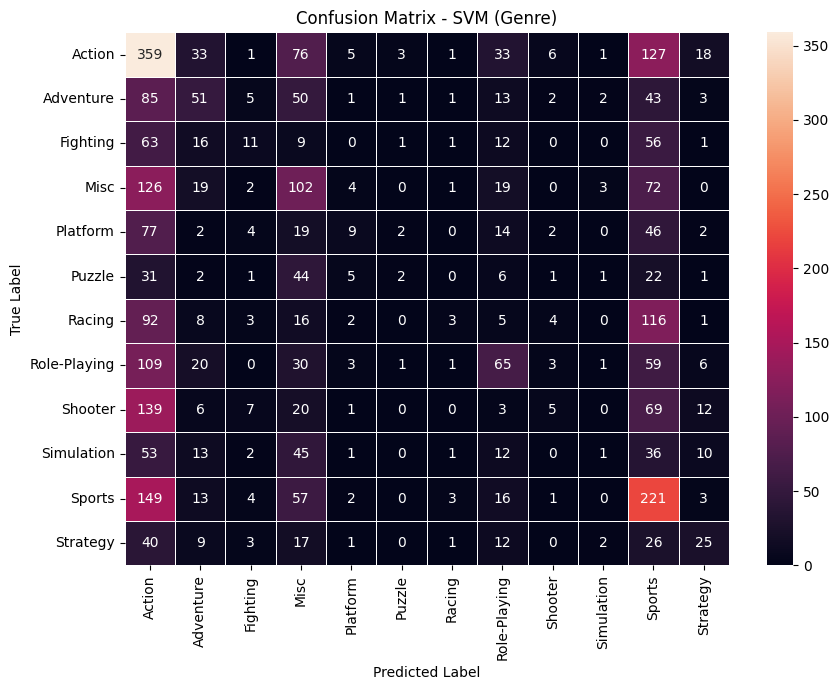

In [8]:
print("\n===== 5) CONFUSION MATRIX =====")
cmx = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
cmx_df = pd.DataFrame(cmx, index=sorted(y.unique()), columns=sorted(y.unique()))
print(cmx_df)

# Visual: Confusion Matrix (Heatmap)
os.makedirs("reports", exist_ok=True)
plt.figure(figsize=(9,7))
sns.heatmap(cmx_df, annot=True, fmt="d", linewidths=0.5, cbar=True)
plt.title("Confusion Matrix - SVM (Genre)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("reports/confusion_matrix_svm_vgsales.png", dpi=300)
plt.show()

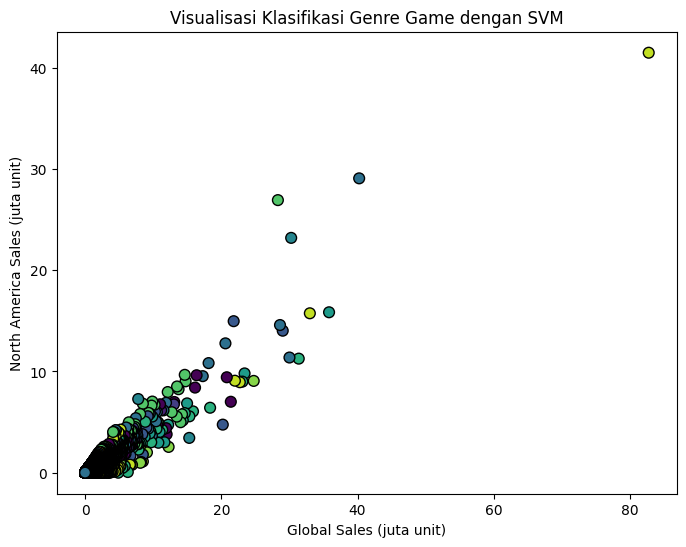

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['Global_Sales'],
    df['NA_Sales'],
    c=df['Genre'].astype('category').cat.codes,
    cmap='viridis', s=60, edgecolor='k'
)

plt.xlabel('Global Sales (juta unit)')
plt.ylabel('North America Sales (juta unit)')
plt.title('Visualisasi Klasifikasi Genre Game dengan SVM')
plt.show()


===== 6) VISUALISASI 2D (PCA) =====


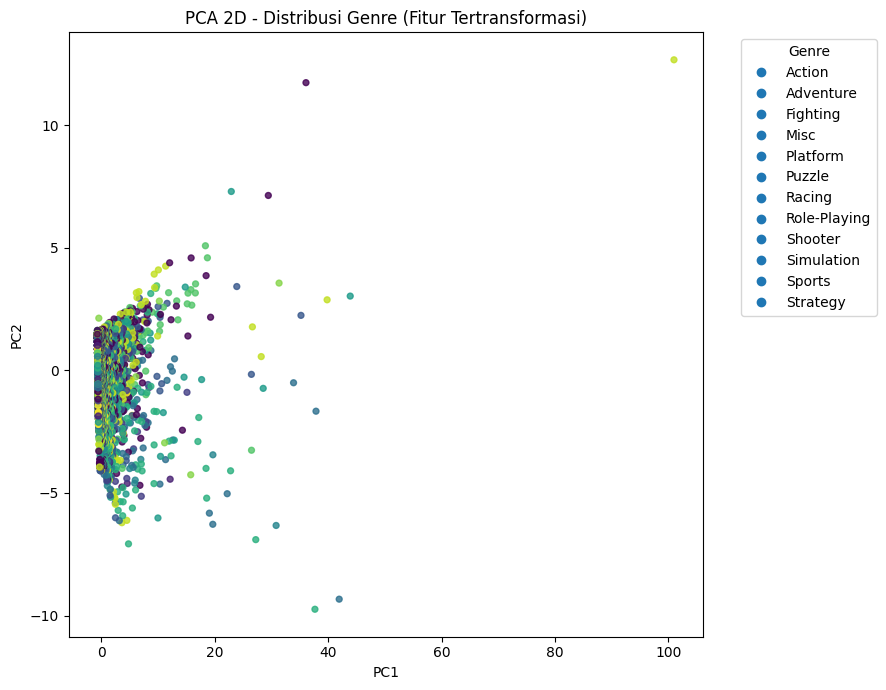

In [9]:
print("\n===== 6) VISUALISASI 2D (PCA) =====")
# Ambil fitur tertransformasi (fit pada seluruh data untuk visual)
feat_all = preprocess.fit_transform(X)
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(feat_all)

# Map label ke integer untuk warna
labels = y.values
classes = sorted(pd.unique(labels))
class_to_int = {c:i for i,c in enumerate(classes)}
colors = [class_to_int[lbl] for lbl in labels]

plt.figure(figsize=(9,7))
scatter = plt.scatter(X_pca2[:,0], X_pca2[:,1], c=colors, s=18, alpha=0.8)
# Buat legend manual
handles = []
for c in classes:
    handles.append(plt.Line2D([0],[0], marker='o', linestyle='', label=c))
plt.legend(handles=handles, title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA 2D - Distribusi Genre (Fitur Tertransformasi)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("reports/pca2d_svm_vgsales.png", dpi=300)
plt.show()


===== 7) VISUALISASI 3D (PCA) =====


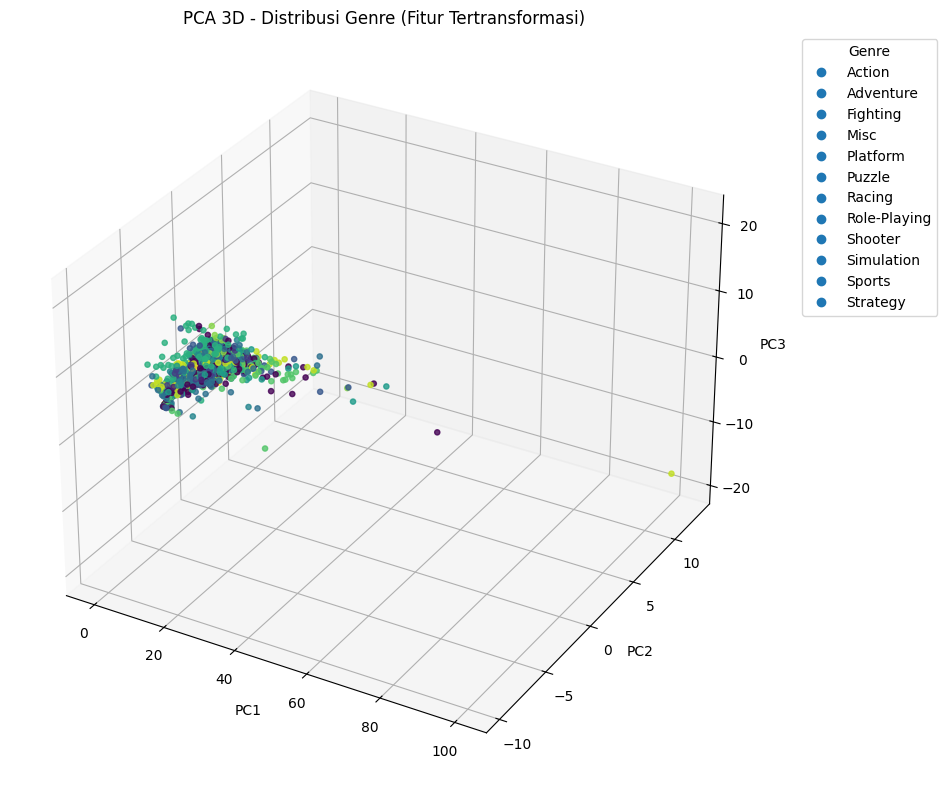

In [10]:
print("\n===== 7) VISUALISASI 3D (PCA) =====")
pca_3d = PCA(n_components=3, random_state=42)
X_pca3 = pca_3d.fit_transform(feat_all)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter3d = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=colors, s=14, alpha=0.8)
ax.set_title("PCA 3D - Distribusi Genre (Fitur Tertransformasi)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
# Legend
legend_elements = [plt.Line2D([0],[0], marker='o', linestyle='', label=c) for c in classes]
ax.legend(handles=legend_elements, title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("reports/pca3d_svm_vgsales.png", dpi=300)
plt.show()